<a href="https://colab.research.google.com/github/StereoWings7/potential-octo-giggle/blob/main/EMNIST_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F #
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import torch.optim as optim
from torchvision import transforms
import kagglehub
import matplotlib.pyplot as plt
%matplotlib inline
import os
from torchvision.datasets import EMNIST, MNIST

In [2]:
mnist_transform = transforms.Compose(
    [
        lambda img: transforms.functional.rotate(img, -90),
        lambda img: transforms.functional.hflip(img),
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
    ]
)

In [3]:
# Get dataset
attacker_dataset_train = EMNIST("emnist", 'balanced', download=True, train=True, transform=mnist_transform)
attacker_dataset_test = EMNIST("emnist", 'balanced', download=True, train=False, transform=mnist_transform)


100%|██████████| 562M/562M [00:09<00:00, 61.5MB/s]


Extracting emnist/EMNIST/raw/gzip.zip to emnist/EMNIST/raw


In [4]:
# Remove lower case letters
attacker_dataset_train.data = attacker_dataset_train.data[attacker_dataset_train.targets <= 35]
attacker_dataset_train.targets = attacker_dataset_train.targets[attacker_dataset_train.targets <= 35]

attacker_dataset_test.data = attacker_dataset_test.data[attacker_dataset_test.targets <= 35]
attacker_dataset_test.targets = attacker_dataset_test.targets[attacker_dataset_test.targets <= 35]

# Keep fewer samples (to reduce execution time of label collection)
attacker_dataset_train.data = attacker_dataset_train.data[:10000]
attacker_dataset_train.targets = attacker_dataset_train.targets[:10000]

attacker_dataset_test.data = attacker_dataset_test.data[:100]
attacker_dataset_test.targets = attacker_dataset_test.targets[:100]


In [5]:
attacker_loader_train = torch.utils.data.DataLoader(attacker_dataset_train, batch_size=64)
attacker_loader_test = torch.utils.data.DataLoader(attacker_dataset_test, batch_size=64)


In [6]:
def plot_images(tensors):
    """ Plot normalised MNIST images """
    fig = plt.figure(figsize=(10, 5))

    n_tensors = len(tensors)
    n_cols = n_tensors
    n_rows = 1

    for row in range(n_rows):
        for col in range(n_cols):
            idx = n_cols * row + col

            if idx > n_tensors - 1:
                break

            ax = fig.add_subplot(n_rows, n_cols, idx + 1)
            tensor = tensors[idx]

            # Clip image values
            tensor[tensor < 0] = 0
            tensor[tensor > 1] = 1

            # Put the channel last
            tensor = torch.permute(tensor, (1, 2, 0))

            ax.imshow(tensor)

    plt.tight_layout()
    plt.show()

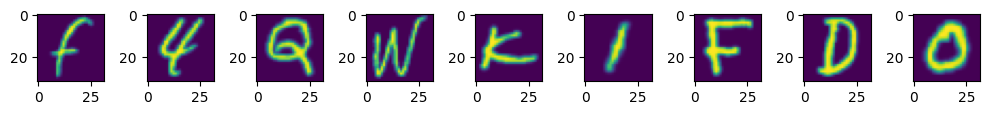

In [7]:
def plot_data(data_loader):
    """ Plot data used to supposedly train the target model """
    images = []

    for _, (data, _) in enumerate(data_loader):
        for i in range(9):
            images.append(data[i])

        break

    plot_images(images)


plot_data(attacker_loader_train)

In [8]:
HEIGHT = 32
WIDTH = 32

In [9]:
# シンプルなCNNモデルの定義(
# ここではconv層2つとしたが、試してみたところもっとシンプルなconv層1つのモデルの方が性能でそう
# (今回学習させてるモデルは小さいので、複雑なモデルは過学習しそう)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes,conv_channels=(32,64),init_method="normal"): # チャネル数をタプルで与えること
        super(SimpleCNN, self).__init__()
        conv1_channels, conv2_channels = conv_channels  # タプルからチャネル数を展開
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, conv1_channels, kernel_size=3, stride=1, padding=1),  # チャネル数は1 → conv1_channels
            nn.BatchNorm2d(conv1_channels), #バッチ正則化
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # ストライド2なので画像サイズは半分に。96 → 48
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(conv1_channels * (WIDTH // 2) * (HEIGHT // 2), 128),  # conv2_channels x 24 x 24 → 128
            nn.ReLU(),
            nn.Dropout(0.2),  # ★ 過学習防止
            nn.Linear(128, num_classes)  # 出力層
        )
        # ★ インスタンス化時にランダム初期化の種類を選択できるようにする
        self.apply(lambda layer: self.init_weights(layer, method=init_method))

    def forward(self, x):
        x = self.conv_layers(x)  # 畳み込み層を通す
        x = x.view(x.size(0), -1)  # 平坦化
        x = self.fc_layers(x)  # 全結合層を通す
        return x

    # ★ 初期化関数（異なる方法を選択可能）
    def init_weights(self, layer, method="normal"):
        if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
            if method == "normal":
                nn.init.normal_(layer.weight, mean=0.0, std=0.1)  # ガウス分布
            elif method == "xavier":
                nn.init.xavier_uniform_(layer.weight)  # Xavier 初期化
            elif method == "kaiming":
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')  # Kaiming 初期化
            elif method == "uniform":
                nn.init.uniform_(layer.weight, a=-0.1, b=0.1)  # 一様分布
            else:
                raise ValueError(f"Unknown initialization method: {method}")

            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0)  # バイアスは0に初期化

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [11]:
# モデルのインスタンス化
num_classes = len(attacker_dataset_train.classes)  # クラス数を取得
model = SimpleCNN(num_classes=num_classes, conv_channels=(32, 64)).to(device)  # モデルをデバイス（GPU/CPU）に転送

In [12]:
# 損失関数と最適化手法の定義
criterion = nn.CrossEntropyLoss()  # 損失関数（クロスエントロピー）
optimizer = optim.Adam(model.parameters(), lr=0.0001)  # Adamオプティマイザ（学習率0.001）

In [13]:
num_epochs = 20  # エポック数
for epoch in range(num_epochs):
    # ======== 学習フェーズ (Training Phase) ========
    model.train()  # モデルを学習モードに設定
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in attacker_loader_train:  # 学習データの各ミニバッチ処理
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()  # 勾配の初期化
        outputs = model(images)  # 順伝播（予測）
        loss = criterion(outputs, labels)  # 損失計算
        loss.backward()  # 逆伝播（勾配計算）
        optimizer.step()  # 最適化（パラメータ更新）

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_acc = correct_train / total_train  # 訓練データの精度を計算

# ======== 検証フェーズ (Validation Phase) ========
    model.eval()  # 検証モード
    correct_val = 0
    total_val = 0

    with torch.no_grad():  # 勾配計算を無効化
        for val_images, val_labels in attacker_loader_test:  # 検証データの全ミニバッチ処理
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            val_outputs = model(val_images)
            _, val_predicted = torch.max(val_outputs, 1)
            total_val += val_labels.size(0)
            correct_val += (val_predicted == val_labels).sum().item()

    val_acc = correct_val / total_val  # 検証データの精度

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(attacker_loader_train):.4f}, "
          f"Train Accuracy: {train_acc:.4f}, Val Accuracy: {val_acc:.4f}")

Epoch 1/20, Loss: 5.2858, Train Accuracy: 0.0744, Val Accuracy: 0.1200
Epoch 2/20, Loss: 3.2724, Train Accuracy: 0.1714, Val Accuracy: 0.2100
Epoch 3/20, Loss: 2.7210, Train Accuracy: 0.2769, Val Accuracy: 0.3900
Epoch 4/20, Loss: 2.2680, Train Accuracy: 0.3794, Val Accuracy: 0.4900
Epoch 5/20, Loss: 1.9473, Train Accuracy: 0.4561, Val Accuracy: 0.5300
Epoch 6/20, Loss: 1.7388, Train Accuracy: 0.5021, Val Accuracy: 0.5600
Epoch 7/20, Loss: 1.5831, Train Accuracy: 0.5407, Val Accuracy: 0.5900
Epoch 8/20, Loss: 1.4526, Train Accuracy: 0.5721, Val Accuracy: 0.6100
Epoch 9/20, Loss: 1.3459, Train Accuracy: 0.6013, Val Accuracy: 0.6400
Epoch 10/20, Loss: 1.2350, Train Accuracy: 0.6256, Val Accuracy: 0.6500
Epoch 11/20, Loss: 1.1575, Train Accuracy: 0.6491, Val Accuracy: 0.6600
Epoch 12/20, Loss: 1.0961, Train Accuracy: 0.6625, Val Accuracy: 0.7100
Epoch 13/20, Loss: 1.0279, Train Accuracy: 0.6803, Val Accuracy: 0.7300
Epoch 14/20, Loss: 0.9683, Train Accuracy: 0.7017, Val Accuracy: 0.7600
E

In [114]:
from IPython.display import HTML, Image
from google.colab.output import eval_js
from base64 import b64decode

canvas_html = """
<canvas width=%d height=%d></canvas>
<button>Finish</button>
<script>
var canvas = document.querySelector('canvas')
var ctx = canvas.getContext('2d')

// 透過PNGだとダメ!アルファチャネルが黒として扱われてしまう。
// 🟢 背景を白にする
ctx.fillStyle = "white";
ctx.fillRect(0, 0, canvas.width, canvas.height);

ctx.lineWidth = %d
ctx.strokeStyle = "black";  // 🟢 線を黒にする
var button = document.querySelector('button')
var mouse = {x: 0, y: 0}
canvas.addEventListener('mousemove', function(e) {
  mouse.x = e.pageX - this.offsetLeft
  mouse.y = e.pageY - this.offsetTop
})
canvas.onmousedown = ()=>{
  ctx.beginPath()
  ctx.moveTo(mouse.x, mouse.y)
  canvas.addEventListener('mousemove', onPaint)
}
canvas.onmouseup = ()=>{
  canvas.removeEventListener('mousemove', onPaint)
}
var onPaint = ()=>{
  ctx.lineTo(mouse.x, mouse.y)
  ctx.stroke()
}
var data = new Promise(resolve=>{
  button.onclick = ()=>{
    resolve(canvas.toDataURL('image/png'))
  }
})
</script>
"""

def draw(filename='drawing.png', w=400, h=200, line_width=1):
  display(HTML(canvas_html % (w, h, line_width)))
  data = eval_js("data")
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return len(binary)

In [132]:
# 線が細すぎるとCNNの畳み込みカーネルが特徴を捉えられない
draw(filename = "/content/drive/MyDrive/Colab Notebooks/data/A.png", w=96, h=96, line_width=6)

1178

1番目候補: A, 確率: 75.64%
2番目候補: B, 確率: 14.54%
3番目候補: E, 確率: 5.87%
4番目候補: F, 確率: 1.03%
5番目候補: 5, 確率: 0.74%
6番目候補: 3, 確率: 0.53%
7番目候補: M, 確率: 0.51%
8番目候補: R, 確率: 0.47%
9番目候補: 8, 確率: 0.17%
10番目候補: K, 確率: 0.17%


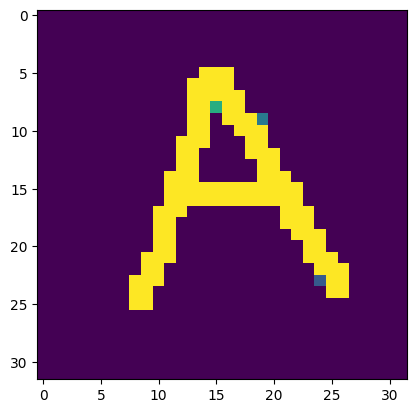

In [133]:
import cv2

# 手書き画像のパス
image_path = "/content/drive/MyDrive/Colab Notebooks/data/A.png"
# OpenCV で画像を読み込む（グレースケールで）
image_cv = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# 画像を 32x32 にリサイズ
image_cv = cv2.resize(image_cv, (32, 32))
# 画像の値を [0,1] に正規化（255で割る）
image_cv = image_cv.astype(np.float32) / 255.0
# 背景が黒・文字が白なら反転
image_cv = 1.0 - image_cv
# OpenCV の配列は (H, W) なので (C, H, W) に変換
image_tensor = torch.tensor(image_cv).unsqueeze(0).unsqueeze(0)  # [1, 1, 32, 32] にする

# 推論
model.eval()
with torch.no_grad():
    output = model(image_tensor.to(device))
    prob = nnf.softmax(output, dim=1).cpu()  # CPUに移して確率計算
    top_p, top_class = prob.topk(10, dim=1)

# 結果表示
for i, (p, c) in enumerate(zip(top_p.view(-1), top_class.view(-1))):
    print(f"{i+1}番目候補: {attacker_dataset_train.classes[c]}, 確率: {float(p*100):.2f}%")
plt.imshow(image_cv)

In [126]:
draw(filename = "/content/drive/MyDrive/Colab Notebooks/data/Q.png", w=96, h=96, line_width=6)

1329

1番目候補: Q, 確率: 97.98%
2番目候補: O, 確率: 1.70%
3番目候補: G, 確率: 0.27%
4番目候補: 0, 確率: 0.01%
5番目候補: R, 確率: 0.01%
6番目候補: U, 確率: 0.01%
7番目候補: X, 確率: 0.00%
8番目候補: 8, 確率: 0.00%
9番目候補: 2, 確率: 0.00%
10番目候補: D, 確率: 0.00%


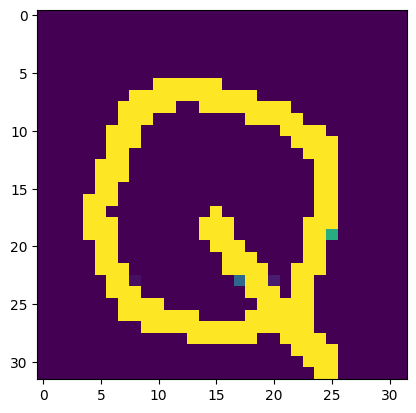

In [128]:
# 手書き画像のパス
image_path = "/content/drive/MyDrive/Colab Notebooks/data/Q.png"
# OpenCV で画像を読み込む（グレースケールで）
image_cv = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
# 画像を 32x32 にリサイズ
image_cv = cv2.resize(image_cv, (32, 32))
# 画像の値を [0,1] に正規化（255で割る）
image_cv = image_cv.astype(np.float32) / 255.0
# 背景が黒・文字が白なら反転
image_cv = 1.0 - image_cv
# OpenCV の配列は (H, W) なので (C, H, W) に変換
image_tensor = torch.tensor(image_cv).unsqueeze(0).unsqueeze(0)  # [1, 1, 32, 32] にする

# 推論
model.eval()
with torch.no_grad():
    output = model(image_tensor.to(device))
    prob = nnf.softmax(output, dim=1).cpu()  # CPUに移して確率計算
    top_p, top_class = prob.topk(10, dim=1)

# 結果表示
for i, (p, c) in enumerate(zip(top_p.view(-1), top_class.view(-1))):
    print(f"{i+1}番目候補: {attacker_dataset_train.classes[c]}, 確率: {float(p*100):.2f}%")
plt.imshow(image_cv)

(32, 32)
1番目候補: 4, 確率: 94.68%
2番目候補: Y, 確率: 2.07%
3番目候補: V, 確率: 1.71%
4番目候補: P, 確率: 0.78%
5番目候補: F, 確率: 0.22%
6番目候補: H, 確率: 0.15%
7番目候補: G, 確率: 0.10%
8番目候補: 9, 確率: 0.06%
9番目候補: 8, 確率: 0.05%
10番目候補: K, 確率: 0.05%


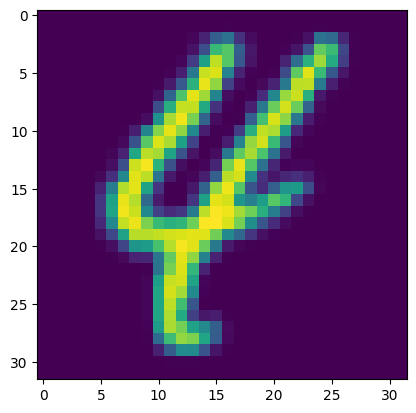

In [84]:
images_minibatch = next(iter(attacker_loader_train)) # images_minibatch[0]は画像、[1] は正解ラベル
image_single = images_minibatch[0][1].detach().cpu().numpy().transpose(1,2,0)
image_single = image_single.reshape((32, 32))  # **ここで 32x32 にリサイズ**
plt.imshow(image_single)
print(image_single.shape)

# 変換を適用
image_tensor = transforms.ToTensor()(image_single)  # [1, 32, 32] の形になる
image_tensor = image_tensor.unsqueeze(0)  # [1, 1, 32, 32] に変換（バッチ次元追加）
# 推論
model.eval()
with torch.no_grad():
    output = model(image_tensor.to(device))
    prob = nnf.softmax(output, dim=1).cpu()  # CPUに移して確率計算
    top_p, top_class = prob.topk(10, dim=1)

# 結果表示
for i, (p, c) in enumerate(zip(top_p.view(-1), top_class.view(-1))):
    print(f"{i+1}番目候補: {attacker_dataset_train.classes[c]}, 確率: {float(p*100):.2f}%")